# Step 1: Define Parameters
To determine a statistically significant sample size from a population of n=1000n=1000 records, we can use statistical principles to ensure that the sample is representative and that the likelihood of missing invalid records is minimized. We'll use the concept of sample size calculation for proportions, which is common in quality control and survey sampling.
Step 1: Define Parameters

1. Population Size (N): 1000 (the total number of records).
2. Confidence Level (Z): Common choices are 90%, 95%, and 99%. For a 95% confidence level, the Z value is approximately 1.96.
3. Margin of Error (E): This is the amount of error you are willing to tolerate. A common choice is 5% (0.05).
4. Estimated Proportion (P): If you have no prior data, you might use 0.5 (50%) since this provides the maximum sample size.

# Step 2: Calculate Sample Size

The formula for calculating the sample size n′ when you have a finite population is:

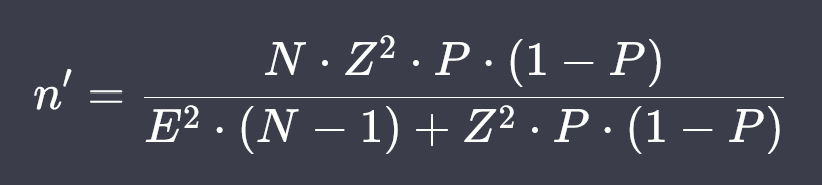

# Where:

- N = Population size (1000)
- Z = Z-score (1.96 for 95% confidence)
- P = Estimated proportion of the attribute of interest (0.5)
- E = Margin of error (0.05)


In [1]:
!pip install pyspark
!pip install python-chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 52.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=0312cecc2cf972ad5200e6f84b4eb44f1e59a8da39980c84a79062dd37871af7
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


In [2]:
from google.colab import drive
import os

# Check if Google Drive is already mounted
if not os.path.exists('/content/drive'):
  drive.mount('/content/drive')
else:
  print("Google Drive already mounted.")

dataFolder = "/content/drive/MyDrive/Colab_Notebooks/00_lichess/03_Triangle"

!ls {dataFolder} -lh


Mounted at /content/drive
total 5.6M
-rw------- 1 root root  56K Nov 13 11:27 '00 01 Filter lichess db for triangle mate patterns'
-rw------- 1 root root  49K Nov 13 12:47 '00 02 Filter lichess db for triangle mate patterns'
-rw------- 1 root root  57K Nov 13 14:15 '00 03 Filter lichess db for triangle mate patterns'
-rw------- 1 root root  49K Nov 13 11:28 '01 01 Filter lichess db for triangle mate patterns V2'
-rw------- 1 root root 1.6M Nov 13 14:15  20251113_lichess_db_puzzle_mate_triangle.csv
-rw------- 1 root root 1.5M Mar 31  2025  lichess_db_puzzle_mate_triangle_spark.csv
-rw------- 1 root root 1.2M Mar 31  2025  lichess_db_puzzle_mate_triangle_V1.csv
-rw------- 1 root root 1.3M Mar 31  2025  lichess_db_puzzle_mate_triangle_V2.csv
-rw------- 1 root root  29K Nov 13 14:18  RandomSelection4Review.ipynb


In [4]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv(f"{dataFolder}/20251113_lichess_db_puzzle_mate_triangle.csv")

match_count = len(df[df['PatternMatch'] == True])

# Print the result
print(f"Matched lines: {match_count}")

Z = 1.96
p = 0.5
E = 0.05

n_qp = match_count * (Z*Z) * p * (1-p)/((E*E) * (match_count - 1) + (Z*Z) * p * (1-p))

print(f"Review size: {n_qp}")

# Randomly sample n_qp records from the DataFrame for Queen-Pawn matting patterns
sampled_df_qp = df[df['PatternMatch'] == True].sample(n=int(n_qp), random_state=42)

# Show the sampled records
print("Sampled Queen-Pawn records (head):")
print(sampled_df_qp.head())
sampled_df_qp.to_csv(f"{dataFolder}/20251113_lichess_db_puzzle_mate_triangle_review.csv", index=False)


Matched lines: 7756
Review size: 366.0752411796794
Sampled Queen-Pawn records (head):
     PuzzleId                                                FEN  \
5086    JQd9d  2r1q1k1/5p2/p3pPp1/2pn3R/P1Pp3Q/1P6/5PPP/6K1 b...   
2465    Naz0d  rn1R1b1r/pp2kq2/4p1Qp/3N4/8/8/PP2PPPP/4KB1R b ...   
6578    XIipm  2b1k1nr/P2q1p2/3p4/3Qp3/4P3/2BP3p/1P2BPPp/R4RK...   
1561    lpZjh  6k1/1b3r2/p5Qp/1p6/2q1pp2/8/P4PPP/3R2K1 b - - ...   
6772    5JlSW  6k1/1p4p1/p1p5/4P1rp/PPpP4/2Pq1r2/6QK/2R3R1 w ...   

                              Moves  Rating  RatingDeviation  Popularity  \
5086            d5f6 h5h8 g8g7 h4h6    1414               75          91   
2465                      e6d5 g6d6    1143               79          87   
6578  g1h2 h3g2 h2g1 h8h1 g1g2 d7h3    1679               75          95   
1561            g8f8 d1d8 f8e7 g6d6    1045               77          90   
6772            g2g5 f3h3 h2g2 d3f3    1732               76          85   

      NbPlays                                   